In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from chronos import Chronos2Pipeline

In [2]:
candidate_paths = [
    Path("data_final/load_1.csv"),
    Path("data final/load_1.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("`load_1.csv`를 찾지 못했습니다. `processed_data/` 경로를 확인하세요.")

df = pd.read_csv(data_path, parse_dates=["time"]).sort_values("time").reset_index(drop=True)
df.head()

,time,load,temp,rhum,dew_point,apparent_temp,precip,rain,snow,press,...,사회,문화,국제,지역,스포츠,IT_과학,범죄,사고,재해,사회_사건사고
0,2012-01-02 00:00:00,185962,-5.074,66.099730,-10.424,-9.024538,0.0,0.0,0.0,1014.72950,...,1184,2284,1113,1818,458,1592,0,185,0,0
1,2012-01-02 01:00:00,184730,-4.924,65.613570,-10.374,-8.855997,0.0,0.0,0.0,1015.13153,...,1184,2284,1113,1818,458,1592,0,185,0,0
2,2012-01-02 02:00:00,181090,-4.824,64.606460,-10.474,-8.649612,0.0,0.0,0.0,1015.23456,...,1184,2284,1113,1818,458,1592,0,185,0,0
3,2012-01-02 03:00:00,186018,-4.724,64.120810,-10.474,-8.434195,0.0,0.0,0.0,1015.53534,...,1184,2284,1113,1818,458,1592,0,185,0,0
4,2012-01-02 04:00:00,186788,-5.524,67.853386,-10.524,-9.353552,0.0,0.0,0.0,1015.70010,...,1184,2284,1113,1818,458,1592,0,185,0,0


In [3]:
prediction_length = 24 * 7
time_col = "time"
target_col = "load"
covariate_cols = [col for col in df.columns if col not in [time_col, target_col]]

# 이 데이터는 주말 구간이 비어 있어 calendar-based frequency를 바로 추론할 수 없습니다.
# 그래서 Chronos-2에는 timestamp 대신 관측 순서 기준 배열 입력을 사용합니다.
train_df = df.iloc[:-prediction_length].copy()
test_df = df.iloc[-prediction_length:].copy()

task = {
    "target": train_df[target_col].to_numpy(dtype="float32"),
    "past_covariates": {
        col: train_df[col].to_numpy(dtype="float32") for col in covariate_cols
    },
    "future_covariates": {
        col: test_df[col].to_numpy(dtype="float32") for col in covariate_cols
    },
}

print(f"data_path: {data_path}")
print(f"rows: {len(df):,}, train: {len(train_df):,}, test: {len(test_df):,}")
print(f"range: {df[time_col].min()} -> {df[time_col].max()}")
print(f"inferred_freq: {pd.infer_freq(df[time_col])}")
print(f"covariates: {len(covariate_cols)}")
task["target"][:5], list(task["past_covariates"].keys())[:5]

data_path: data_final/load_1.csv
rows: 17,760, train: 17,592, test: 168
range: 2012-01-02 00:00:00 -> 2014-12-31 23:00:00
inferred_freq: None
covariates: 70


(array([185962., 184730., 181090., 186018., 186788.], dtype=float32),
 ['temp', 'rhum', 'dew_point', 'apparent_temp', 'precip'])

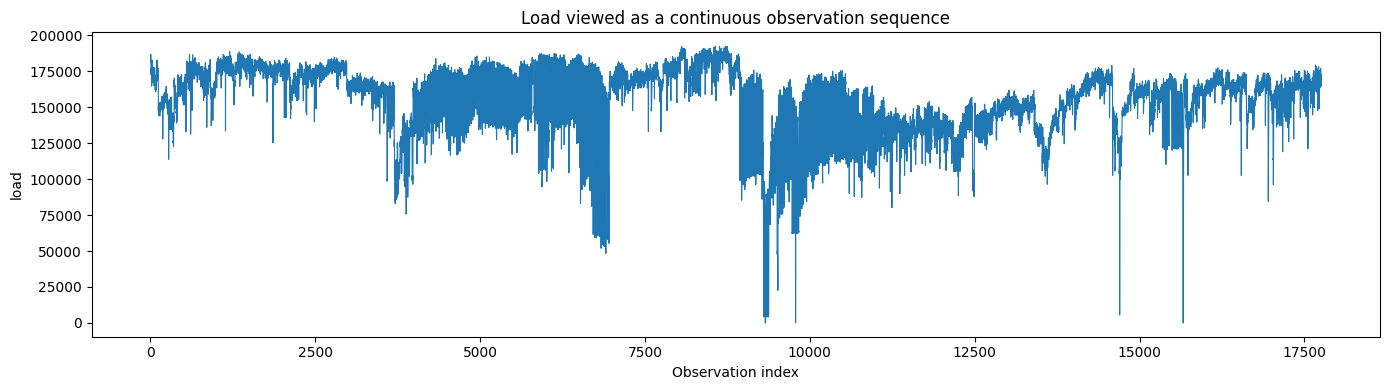

,time,obs_idx,load
0,2012-01-02 00:00:00,0,185962
1,2012-01-02 01:00:00,1,184730
2,2012-01-02 02:00:00,2,181090
3,2012-01-02 03:00:00,3,186018
4,2012-01-02 04:00:00,4,186788


In [4]:
# 실제 시각축(time) 대신 관측 순서(obs_idx)로 이어서 보기
df_plot = df.copy()
df_plot["obs_idx"] = range(len(df_plot))

plt.figure(figsize=(14, 4))
plt.plot(df_plot["obs_idx"], df_plot[target_col], linewidth=0.8)
plt.title("Load viewed as a continuous observation sequence")
plt.xlabel("Observation index")
plt.ylabel(target_col)
plt.tight_layout()
plt.show()

df_plot[[time_col, "obs_idx", target_col]].head()

device=cuda, MAE=6,630.80, RMSE=8,032.79


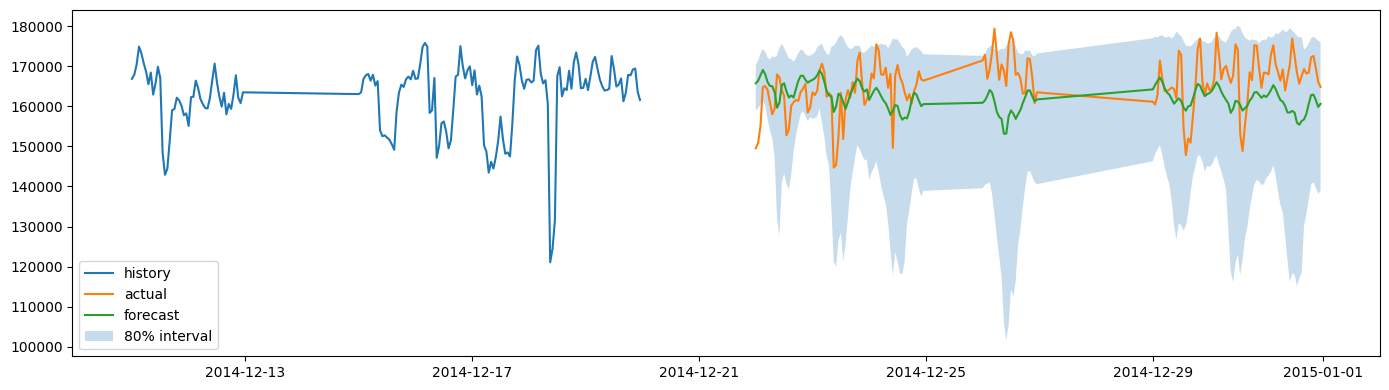

,timestamp,actual,predictions,0.1,0.5,0.9
0,2014-12-22 00:00:00,149520,165761.421875,158932.968750,165761.421875,170357.750000
1,2014-12-22 01:00:00,150864,166415.671875,159630.734375,166415.671875,171474.406250
2,2014-12-22 02:00:00,155120,167801.453125,160487.328125,167801.453125,173152.750000
3,2014-12-22 03:00:00,164864,169102.031250,161588.078125,169102.031250,174330.968750
4,2014-12-22 04:00:00,165088,168023.562500,160134.765625,168023.562500,173643.390625


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map=device)

quantile_levels = [0.1, 0.5, 0.9]
quantiles, mean = pipeline.predict_quantiles(
    [task],
    prediction_length=prediction_length,
    quantile_levels=quantile_levels,
)

q = quantiles[0].squeeze(0).cpu().numpy()
pred = mean[0].squeeze(0).cpu().numpy()

result = pd.DataFrame({
    "timestamp": test_df[time_col].to_numpy(),
    "actual": test_df[target_col].to_numpy(),
    "predictions": pred,
    "0.1": q[:, 0],
    "0.5": q[:, 1],
    "0.9": q[:, 2],
})

mae = (result["predictions"] - result["actual"]).abs().mean()
rmse = ((result["predictions"] - result["actual"]) ** 2).mean() ** 0.5
print(f"device={device}, MAE={mae:,.2f}, RMSE={rmse:,.2f}")

plt.figure(figsize=(14, 4))
plt.plot(train_df[time_col].tail(24 * 7), train_df[target_col].tail(24 * 7), label="history")
plt.plot(result["timestamp"], result["actual"], label="actual")
plt.plot(result["timestamp"], result["predictions"], label="forecast")
plt.fill_between(result["timestamp"], result["0.1"], result["0.9"], alpha=0.25, label="80% interval")
plt.legend()
plt.tight_layout()
plt.show()

result.head()

In [2]:
from chronos2_multiseries_finetune import (
    build_finetune_inputs,
    extract_prediction_attention,
    extract_window_attention,
    extract_window_attentions,
    finetune_pipeline,
    load_series_splits,
    rolling_evaluate,
    summarize_results,
    summarize_window_attentions,
    load_finetuned_pipeline
)

In [5]:
TRAIN_END = "2012-12-31 23:00:00"
TEST_START = "2013-01-01 00:00:00"
PREDICTION_LENGTH = 24
WINDOW_STRIDE = 24

# 전체 실험은 둘 다 None으로 두면 됩니다.
# 처음 확인할 때만 예: MAX_SERIES = 20, MAX_WINDOWS = 5
MAX_SERIES = None
MAX_WINDOWS = None

FINETUNE_MODE = "lora"
NUM_STEPS = 30000
FT_BATCH_SIZE = 64
PRED_BATCH_SIZE = 64
CONTEXT_LENGTH = 168
OUTPUT_DIR = "outputs/FINAL"

In [7]:
series_splits, covariate_cols = load_series_splits(
    data_dir="data_final",
    train_end=TRAIN_END,
    test_start=TEST_START,
    max_series=MAX_SERIES,
    use_covariates=True,
)

train_inputs = build_finetune_inputs(series_splits)
total_test_windows = sum(len(split.test_target) // PREDICTION_LENGTH for split in series_splits)

pd.Series(
    {
        "n_series": len(series_splits),
        "n_covariates": len(covariate_cols),
        "train_min_len": min(len(split.train_target) for split in series_splits),
        "train_max_len": max(len(split.train_target) for split in series_splits),
        "test_min_len": min(len(split.test_target) for split in series_splits),
        "test_max_len": max(len(split.test_target) for split in series_splits),
        "total_24step_windows": total_test_windows,
    }
)

n_series                   763
n_covariates                70
train_min_len             1848
train_max_len             6048
test_min_len              7704
test_max_len             11928
total_24step_windows    374761
dtype: int64

In [9]:
finetuned_pipeline, ft_device = finetune_pipeline(
    train_inputs=train_inputs,
    prediction_length=PREDICTION_LENGTH,
    finetune_mode=FINETUNE_MODE,
    num_steps=NUM_STEPS,
    batch_size=FT_BATCH_SIZE,
    context_length=CONTEXT_LENGTH,
    output_dir=OUTPUT_DIR,
)

print(ft_device)

Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
3000,0.046400
6000,0.043500
9000,0.043400
12000,0.043700
15000,0.043900
18000,0.042300
21000,0.043300
24000,0.041100
27000,0.042200
30000,0.042800


cuda


In [3]:
reloaded_pipeline, device = load_finetuned_pipeline(
    "outputs/FINAL/finetuned-ckpt"
)

print(device)

cuda


In [20]:
file_ids = []

for i in range(26,27):
    file_ids.append(f'load_{i}')

file_ids

['load_26']

In [21]:
results = rolling_evaluate(
    pipeline=reloaded_pipeline,
    series_splits=series_splits,
    prediction_length=PREDICTION_LENGTH,
    batch_size=PRED_BATCH_SIZE,
    window_stride=WINDOW_STRIDE,
    max_windows=MAX_WINDOWS,
    max_context=CONTEXT_LENGTH,
    series_ids=file_ids
)


In [22]:
summary = summarize_results(results)
print(summary)

n_rows    11856.000000
mae          85.365044
rmse        146.443268
mape          7.349630
dtype: float64


In [14]:
import pandas as pd
import numpy as np

# 1. 계산 함수 정의 (Zero-division 방지 로직 포함)
def calculate_metrics(group):
    actual = group['actual'].values
    pred = group['predictions'].values
    
    # MAE (Mean Absolute Error)
    mae = np.mean(np.abs(actual - pred))
    
    # MAPE & MPE 계산을 위한 마스킹 (actual이 0인 지점 제외)
    mask = actual != 0
    if np.any(mask):
        actual_m = actual[mask]
        pred_m = pred[mask]
        
        # MAPE (Mean Absolute Percentage Error)
        mape = np.mean(np.abs((actual_m - pred_m) / actual_m)) * 100
        # MPE (Mean Percentage Error)
        mpe = np.mean((actual_m - pred_m) / actual_m) * 100
    else:
        mape = mpe = np.nan
        
    return pd.Series({'MAE': mae, 'MAPE': mape, 'MPE': mpe})

# 2. Groupby 적용
# results 데이터프레임에 'series_id', 'actual', 'predictions' 컬럼이 있다고 가정합니다.
final_metrics = results.groupby('series_id').apply(calculate_metrics)

# 3. 전체 평균 및 요약 출력
print("--- 각 Series별 요약 통계 ---")
print(final_metrics.describe())

# 4. 성능이 가장 안 좋은(MAPE가 높은) Top 5 추출
print("\n--- 성능 저하 Series Top 5 (MAPE 기준) ---")
print(final_metrics.sort_values(by='MAPE', ascending=False).head(5))

# 5. CSV로 결과 저장 (DGX 서버 분석용)
# final_metrics.to_csv("metrics_by_series.csv")

--- 각 Series별 요약 통계 ---
                MAE         MAPE          MPE
count    763.000000   763.000000   763.000000
mean     489.870331    29.376854   -20.771307
std     2095.248291    94.586372    92.237839
min        0.542556     0.418892 -1464.551392
25%       21.852814     5.589931   -10.198622
50%       72.732910    10.746537    -2.537946
75%      211.427368    21.791853    -0.680951
max    29033.300781  1477.846069    10.544790

--- 성능 저하 Series Top 5 (MAPE 기준) ---
                   MAE         MAPE          MPE
series_id                                       
load_51      30.395102  1477.846069 -1464.551392
load_157    340.425659  1403.357056 -1361.486084
load_203   1075.238770   943.680298  -935.352539
load_380    637.054321   744.226257  -712.399841
load_371   2212.984131   518.086792  -473.743530


/tmp/ipykernel_3066567/789018882.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final_metrics = results.groupby('series_id').apply(calculate_metrics)


In [15]:
#results = pd.read_csv('outputs/chronos2_ft_news_cnt_24step.csv')

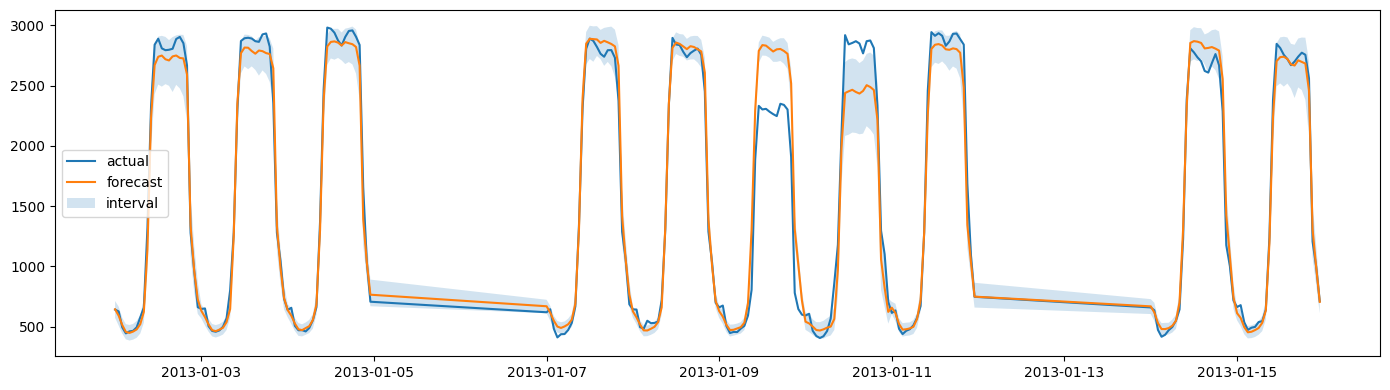

In [16]:
file_num = 26
end = 24 * 10
result = results[results['series_id'] == f'load_{file_num}'][:end]

plt.figure(figsize=(14, 4))
plt.plot(result["timestamp"], result["actual"], label="actual")
plt.plot(result["timestamp"], result["predictions"], label="forecast")
if {"0.1", "0.9"}.issubset(result.columns):
    plt.fill_between(result["timestamp"], result["0.1"], result["0.9"], alpha=0.2, label="interval")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
results.to_csv("PREDICTION_RESULTS/24step_FINAL.csv", index=False)
print("saved to PREDICTION_RESULTS/24step_FINAL.csv")

saved to PREDICTION_RESULTS/24step_FINAL.csv


In [8]:
# Attention extraction setup for XAI / LLM prompts
ATTN_SERIES_ID = "load_26"
ATTN_WINDOW_STRIDE = PREDICTION_LENGTH
ATTN_MAX_WINDOWS = None
ATTN_WINDOW_STARTS = None  # e.g. [0, 12, 24]
SELECTED_ATTN_WINDOW_START = None  # None -> first extracted window

attention_split = next(split for split in series_splits if split.series_id == ATTN_SERIES_ID)
pd.Series(
    {
        "attention_series_id": ATTN_SERIES_ID,
        "window_stride": ATTN_WINDOW_STRIDE,
        "max_windows": ATTN_MAX_WINDOWS,
        "window_starts": str(ATTN_WINDOW_STARTS),
        "prediction_length": PREDICTION_LENGTH,
        "context_length": CONTEXT_LENGTH,
    }
)

attention_series_id    load_26
window_stride               24
max_windows               None
window_starts             None
prediction_length           24
context_length             168
dtype: object

In [9]:
attention_bundles = extract_window_attentions(
    pipeline=reloaded_pipeline,
    split=attention_split,
    prediction_length=PREDICTION_LENGTH,
    max_context=CONTEXT_LENGTH,
    window_stride=ATTN_WINDOW_STRIDE,
    window_starts=ATTN_WINDOW_STARTS,
    max_windows=ATTN_MAX_WINDOWS,
)

attention_summary = summarize_window_attentions(attention_bundles)
if attention_summary.empty:
    raise ValueError("No attention windows were extracted. Check ATTN_WINDOW_STARTS / ATTN_MAX_WINDOWS.")

attention_summary

,series_id,window_idx,window_start,window_end,timestamp_start,timestamp_end,attention_fingerprint,n_row_labels,n_token_labels,target_query_label,top_source_label,top_source_attention,time_attn_shape,group_attn_shape
0,load_26,0,0,24,2013-01-02 00:00:00,2013-01-02 23:00:00,0d1142d306defe02,71,14,target,target,0.027768,"(12, 71, 12, 14, 14)","(12, 14, 12, 71, 71)"
1,load_26,1,24,48,2013-01-03 00:00:00,2013-01-03 23:00:00,b850eb5000d14ed0,71,14,target,target,0.027663,"(12, 71, 12, 14, 14)","(12, 14, 12, 71, 71)"
2,load_26,2,48,72,2013-01-04 00:00:00,2013-01-04 23:00:00,60e9e47fef9f863b,71,14,target,target,0.026262,"(12, 71, 12, 14, 14)","(12, 14, 12, 71, 71)"
3,load_26,3,72,96,2013-01-07 00:00:00,2013-01-07 23:00:00,c0329482a35112ad,71,14,target,target,0.028450,"(12, 71, 12, 14, 14)","(12, 14, 12, 71, 71)"
4,load_26,4,96,120,2013-01-08 00:00:00,2013-01-08 23:00:00,a6975b471a15d4e7,71,14,target,target,0.027784,"(12, 71, 12, 14, 14)","(12, 14, 12, 71, 71)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,load_26,489,11736,11760,2014-12-24 00:00:00,2014-12-24 23:00:00,a1aa32cec228d963,71,14,target,target,0.027587,"(12, 71, 12, 14, 14)","(12, 14, 12, 71, 71)"
490,load_26,490,11760,11784,2014-12-26 00:00:00,2014-12-26 23:00:00,ab97f7864257375f,71,14,target,target,0.026990,"(12, 71, 12, 14, 14)","(12, 14, 12, 71, 71)"
491,load_26,491,11784,11808,2014-12-29 00:00:00,2014-12-29 23:00:00,2d518e196ca5c9c7,71,14,target,target,0.027084,"(12, 71, 12, 14, 14)","(12, 14, 12, 71, 71)"
492,load_26,492,11808,11832,2014-12-30 00:00:00,2014-12-30 23:00:00,2de562ef5a08a1cf,71,14,target,target,0.027332,"(12, 71, 12, 14, 14)","(12, 14, 12, 71, 71)"


In [10]:
attention_summary.to_csv('load_26_attn_summary.csv', index=False)

In [15]:
# Compact payloads for downstream XAI / LLM analysis
target_idx = 0

xai_payloads = []
for bundle in attention_bundles:
    xai_payloads.append(
        {
            "series_id": bundle["series_id"],
            "window_idx": bundle["window_idx"],
            "window_start": bundle["window_start"],
            "window_end": bundle["window_end"],
            "attention_fingerprint": bundle["attention_fingerprint"],
            "row_labels": bundle["row_labels"],
            "token_labels": bundle["token_labels"],
            "window_timestamps": pd.to_datetime(bundle["window_timestamps"]).astype(str).tolist(),
            "time_attn_shape": list(bundle["time_attn"].shape),
            "group_attn_shape": list(bundle["group_attn"].shape),
            "time_attention_target_mean": bundle["time_attn"][:, target_idx].mean(dim=(0, 1)).numpy().tolist(),
            "group_attention_mean": bundle["group_attn"].mean(dim=(0, 1, 2)).numpy().tolist(),
        }
    )

if SELECTED_ATTN_WINDOW_START is None:
    SELECTED_ATTN_WINDOW_START = int(attention_summary.iloc[0]["window_start"])

attention_bundle = next(
    bundle for bundle in attention_bundles if bundle["window_start"] == SELECTED_ATTN_WINDOW_START
)
xai_payload = next(
    payload for payload in xai_payloads if payload["window_start"] == SELECTED_ATTN_WINDOW_START
)

pd.Series(
    {
        "series_id": attention_bundle["series_id"],
        "selected_window_start": attention_bundle["window_start"],
        "selected_window_end": attention_bundle["window_end"],
        "window_idx": attention_bundle["window_idx"],
        "attention_fingerprint": attention_bundle["attention_fingerprint"],
        "n_extracted_windows": len(attention_bundles),
        "row_labels": ", ".join(attention_bundle["row_labels"]),
        "token_preview": ", ".join(attention_bundle["token_labels"][:8]),
    }
)

series_id                                                          load_26
selected_window_start                                                    0
selected_window_end                                                     24
window_idx                                                               0
attention_fingerprint                                     0d1142d306defe02
n_extracted_windows                                                    494
row_labels               target, known_future:IT_과학, known_future:appar...
token_preview            context_patch_0, context_patch_1, context_patc...
dtype: object

In [16]:
xai_payload

{'series_id': 'load_26',
 'window_idx': 0,
 'window_start': 0,
 'window_end': 24,
 'attention_fingerprint': '0d1142d306defe02',
 'row_labels': ['target',
  'known_future:IT_과학',
  'known_future:apparent_temp',
  'known_future:cloud',
  'known_future:dew_point',
  'known_future:diffuse_rad',
  'known_future:direct_rad',
  'known_future:pca_embedding_0',
  'known_future:pca_embedding_1',
  'known_future:pca_embedding_10',
  'known_future:pca_embedding_11',
  'known_future:pca_embedding_12',
  'known_future:pca_embedding_13',
  'known_future:pca_embedding_14',
  'known_future:pca_embedding_15',
  'known_future:pca_embedding_16',
  'known_future:pca_embedding_17',
  'known_future:pca_embedding_18',
  'known_future:pca_embedding_19',
  'known_future:pca_embedding_2',
  'known_future:pca_embedding_20',
  'known_future:pca_embedding_21',
  'known_future:pca_embedding_22',
  'known_future:pca_embedding_23',
  'known_future:pca_embedding_24',
  'known_future:pca_embedding_25',
  'known_future:p

In [13]:
group_attn = attention_bundle["group_attn"].float()
row_labels = attention_bundle["row_labels"]
token_labels = attention_bundle["token_labels"]
time_attn = attention_bundle["time_attn"].float()

pd.Series(
    {
        "series_id": attention_bundle["series_id"],
        "window_start": attention_bundle["window_start"],
        "window_end": attention_bundle["window_end"],
        "time_attn_shape": str(tuple(time_attn.shape)),
        "group_attn_shape": str(tuple(group_attn.shape)),
        "n_row_labels": len(row_labels),
        "n_token_labels": len(token_labels),
        "row_labels": ", ".join(row_labels),
        "token_preview": ", ".join(token_labels[:8]),
    }
)


NameError: name 'group_attn' is not defined

In [14]:
group_attn_mean = group_attn.mean(dim=(0, 1, 2)).cpu().numpy()  # [R, R]

group_attn_df = pd.DataFrame(
    group_attn_mean,
    index=row_labels,   # query row
    columns=row_labels, # key row
)

group_attn_df


NameError: name 'group_attn' is not defined

In [17]:
target_rows = [label for label in row_labels if label.startswith("target")]
combined_cols = [label for label in row_labels if not label.startswith("target")]

if not target_rows:
    raise ValueError(f"No target row found in row_labels: {row_labels}")

target_to_combined = (
    group_attn_df.loc[target_rows, combined_cols]
    .T
    .sort_values(by=target_rows[0], ascending=False)
)

target_to_combined


NameError: name 'row_labels' is not defined

In [18]:
target_label = target_rows[0]

target_to_combined_series = (
    group_attn_df.loc[target_label, combined_cols]
    .sort_values(ascending=False)
)

target_to_combined_series


NameError: name 'target_rows' is not defined

In [19]:
import json

with open("load_26_xai_payloads.json", "w", encoding="utf-8") as f:
    json.dump(xai_payloads, f, ensure_ascii=False, indent=2)